# MinHash and LSH Implementation for Document Similarity

In [33]:
import numpy as np
import hashlib
import time
import random
from collections import defaultdict
import matplotlib.pyplot as plt

In [34]:
class MinHashLSH:
    def __init__(self, num_hashes=100, num_bands=20):
        self.num_hashes = num_hashes
        self.num_bands = num_bands
        self.rows_per_band = num_hashes // num_bands
        
        self.hash_params = []
        for _ in range(num_hashes):
            a = random.randint(1, 2**32 - 1)
            b = random.randint(0, 2**32 - 1)
            self.hash_params.append((a, b))
    
    def get_shingles(self, text, k=3):
        text = text.lower().strip()
        shingles = set()
        for i in range(len(text) - k + 1):
            shingles.add(text[i:i+k])
        return shingles
    
    def hash_shingle(self, shingle):
        return int(hashlib.md5(shingle.encode()).hexdigest(), 16) % (2**32)
    
    def compute_minhash_signature(self, shingles):
        signature = []
        shingle_hashes = [self.hash_shingle(s) for s in shingles]
        
        for a, b in self.hash_params:
            min_hash = float('inf')
            for sh in shingle_hashes:
                hash_val = (a * sh + b) % (2**32)
                min_hash = min(min_hash, hash_val)
            signature.append(min_hash)
        
        return signature
    
    def jaccard_similarity_from_signatures(self, sig1, sig2):
        matches = sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i])
        return matches / len(sig1)
    
    def true_jaccard_similarity(self, shingles1, shingles2):
        intersection = len(shingles1.intersection(shingles2))
        union = len(shingles1.union(shingles2))
        return intersection / union if union > 0 else 0
    
    def lsh_hash_band(self, signature_band, band_idx):
        band_str = str(band_idx) + ''.join(map(str, signature_band))
        return hashlib.md5(band_str.encode()).hexdigest()
    
    def find_candidate_pairs_lsh(self, signatures, threshold=0.8):
        buckets = defaultdict(list)
        
        for doc_id, signature in enumerate(signatures):
            for band_idx in range(self.num_bands):
                start = band_idx * self.rows_per_band
                end = start + self.rows_per_band
                band = signature[start:end]
                bucket_hash = self.lsh_hash_band(band, band_idx)
                buckets[bucket_hash].append(doc_id)
        
        candidate_pairs = set()
        for bucket in buckets.values():
            if len(bucket) > 1:
                for i in range(len(bucket)):
                    for j in range(i + 1, len(bucket)):
                        candidate_pairs.add((bucket[i], bucket[j]))
        
        return candidate_pairs
    
    def brute_force_similarity(self, documents, threshold=0.8):
        similar_pairs = []
        n = len(documents)
        
        for i in range(n):
            for j in range(i + 1, n):
                shingles1 = self.get_shingles(documents[i])
                shingles2 = self.get_shingles(documents[j])
                similarity = self.true_jaccard_similarity(shingles1, shingles2)
                if similarity >= threshold:
                    similar_pairs.append((i, j, similarity))
        
        return similar_pairs

## Document Generation

In [35]:
def generate_sample_documents(num_docs=500):    
    base_texts = [
        "Machine learning is a subset of artificial intelligence that enables computers to learn and make decisions from data without being explicitly programmed.",
        "Deep learning uses neural networks with multiple layers to model and understand complex patterns in data.",
        "Natural language processing allows computers to understand, interpret, and generate human language in a valuable way.",
        "Computer vision enables machines to interpret and make decisions based on visual data from the world around them.",
        "Data science combines statistics, programming, and domain expertise to extract insights from large datasets.",
        "Artificial intelligence aims to create systems that can perform tasks that typically require human intelligence.",
        "Big data refers to extremely large datasets that require specialized tools and techniques to process and analyze.",
        "Cloud computing provides on-demand access to computing resources over the internet without direct management.",
        "Cybersecurity protects digital systems, networks, and data from digital attacks and unauthorized access.",
        "Software engineering is the systematic approach to designing, developing, and maintaining software systems.",
        "Database management systems organize and store data in a way that allows for efficient retrieval and manipulation.",
        "Web development involves creating websites and web applications using various programming languages and frameworks.",
        "Mobile app development focuses on creating applications for smartphones and tablets across different platforms.",
        "DevOps combines development and operations to improve collaboration and productivity in software development.",
        "Blockchain technology creates a distributed ledger that maintains a continuously growing list of records.",
        "Internet of Things connects everyday objects to the internet, enabling them to send and receive data.",
        "Quantum computing uses quantum mechanical phenomena to perform operations on data in fundamentally new ways.",
        "Augmented reality overlays digital information onto the real world, enhancing user perception and interaction.",
        "Virtual reality creates immersive, computer-generated environments that users can interact with naturally.",
        "Robotics combines mechanical engineering, electrical engineering, and computer science to create autonomous machines."
    ]
    
    documents = []
    
    # Create exact duplicates (10% of documents)
    for i in range(num_docs // 10):
        documents.append(base_texts[i % len(base_texts)])
    
    # Create near-duplicates with small modifications (20% of documents)
    for i in range(num_docs // 5):
        base_text = base_texts[i % len(base_texts)]
        # Add small variations
        variations = [
            base_text + " This technology continues to evolve rapidly.",
            base_text + " It has many applications in modern industry.",
            base_text.replace("systems", "platforms").replace("data", "information"),
            "In recent years, " + base_text.lower(),
            base_text + " Researchers are actively working on improvements."
        ]
        documents.append(variations[i % len(variations)])
    
    # Create unique documents (70% of documents)
    topics = ["technology", "science", "business", "education", "health", "environment", "sports", "entertainment"]
    for i in range((num_docs * 7) // 10):
        topic = topics[i % len(topics)]
        length = random.randint(50, 200)
        # Generate pseudo-random text based on topic
        words = [f"{topic}_{j}" for j in range(length // 10)]
        random.shuffle(words)
        text = " ".join(words[:length//10]) + f" in the field of {topic} research and development."
        documents.append(text)
    
    return documents

print("Generating 500 sample documents...")
documents = generate_sample_documents(500)
print(f"Generated {len(documents)} documents")

Generating 500 sample documents...
Generated 500 documents


# MinHashLSH Initialization

In [36]:
print("\nInitializing MinHash LSH...")
minhash_lsh = MinHashLSH(num_hashes=100, num_bands=20)


Initializing MinHash LSH...


## MinHash Signatures Computation

In [37]:
print("\nComputing MinHash signatures...")
start_time = time.time()
signatures = []
all_shingles = []

for i, doc in enumerate(documents):
    shingles = minhash_lsh.get_shingles(doc)
    all_shingles.append(shingles)
    signature = minhash_lsh.compute_minhash_signature(shingles)
    signatures.append(signature)
    
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} documents...")

signature_time = time.time() - start_time
print(f"MinHash signature computation completed in {signature_time:.2f} seconds")


Computing MinHash signatures...
Processed 100 documents...
Processed 200 documents...
Processed 300 documents...
Processed 400 documents...
Processed 500 documents...
MinHash signature computation completed in 1.13 seconds


## LSH for finding candidate pairs

In [38]:
print("\nFinding candidate pairs using LSH...")
start_time = time.time()
candidate_pairs = minhash_lsh.find_candidate_pairs_lsh(signatures, threshold=0.8)
lsh_time = time.time() - start_time

print(f"LSH found {len(candidate_pairs)} candidate pairs in {lsh_time:.2f} seconds")

print("Verifying candidate pairs...")
verified_pairs = []
for i, j in candidate_pairs:
    similarity = minhash_lsh.jaccard_similarity_from_signatures(signatures[i], signatures[j])
    if similarity >= 0.8:
        verified_pairs.append((i, j, similarity))

print(f"Found {len(verified_pairs)} pairs with similarity >= 80%")


Finding candidate pairs using LSH...
LSH found 26874 candidate pairs in 0.04 seconds
Verifying candidate pairs...
Found 8230 pairs with similarity >= 80%


## Brute force comparison

In [39]:
print("\nBrute force comparison...")
start_time = time.time()
brute_force_pairs = minhash_lsh.brute_force_similarity(documents, threshold=0.8)
brute_force_time = time.time() - start_time

print(f"Brute force found {len(brute_force_pairs)} similar pairs in {brute_force_time:.2f} seconds")

print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)
print(f"LSH Method:")
print(f"  - Time: {lsh_time:.2f} seconds")
print(f"  - Candidate pairs: {len(candidate_pairs)}")
print(f"  - Verified similar pairs: {len(verified_pairs)}")
print(f"  - Speedup: {brute_force_time/lsh_time:.2f}x")

print(f"\nBrute Force Method:")
print(f"  - Time: {brute_force_time:.2f} seconds")
print(f"  - Similar pairs found: {len(brute_force_pairs)}")


Brute force comparison...
Brute force found 5735 similar pairs in 4.27 seconds

PERFORMANCE COMPARISON
LSH Method:
  - Time: 0.04 seconds
  - Candidate pairs: 26874
  - Verified similar pairs: 8230
  - Speedup: 113.42x

Brute Force Method:
  - Time: 4.27 seconds
  - Similar pairs found: 5735


## Analysis of different band configurations


Analyzing different band configurations...
Testing 4 bands...
Testing 5 bands...
Testing 10 bands...
Testing 20 bands...
Testing 25 bands...
Testing 50 bands...

BAND CONFIGURATION ANALYSIS
Bands  Rows/Band  Candidates   Verified   Time(s)  Precision  Recall  
----------------------------------------------------------------------
4      25         2613         2613       0.008    1.000      0.456   
5      20         3677         3677       0.010    1.000      0.641   
10     10         8631         7901       0.015    0.915      1.378   
20     5          26874        8230       0.028    0.306      1.435   
25     4          54046        8230       0.068    0.152      1.435   
50     2          78944        8230       0.124    0.104      1.435   


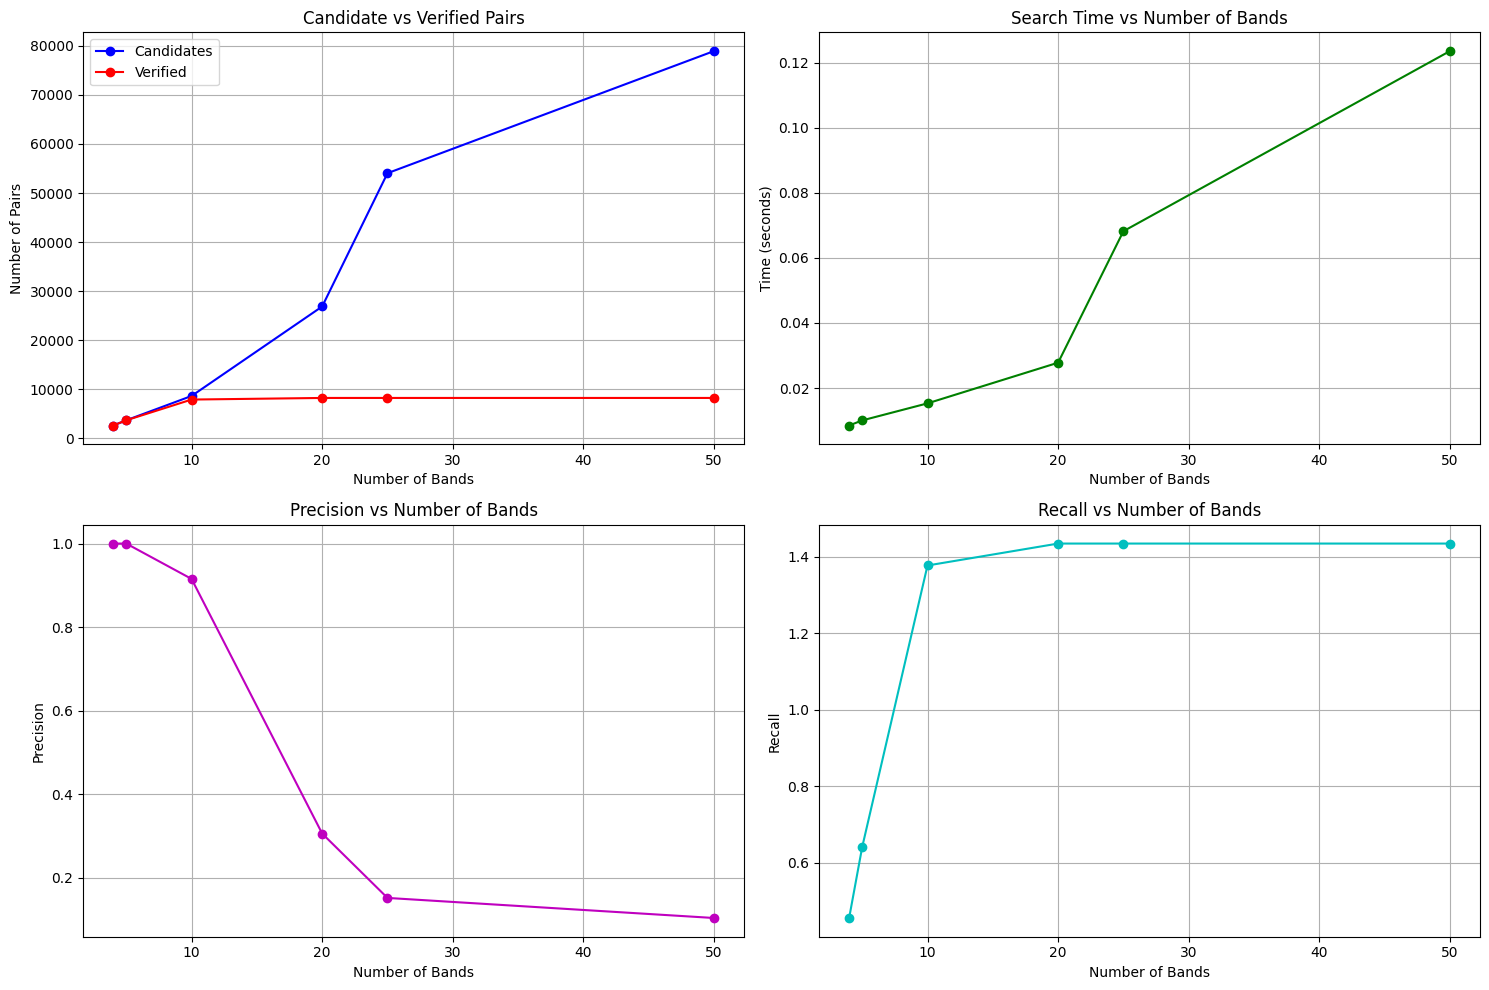


SUMMARY STATISTICS
Total documents processed: 500
MinHash signature length: 100
Average shingles per document: 93.3
LSH bands used: 20
Rows per band: 5

Sample of similar pairs found:

Pair 1 (similarity: 0.830):
Doc 155: environment_4 environment_8 environment_17 environment_0 environment_12 environment_16 environment_1...
Doc 437: entertainment_3 entertainment_8 entertainment_10 entertainment_11 entertainment_1 entertainment_5 en...

Pair 2 (similarity: 0.890):
Doc 295: science_2 science_1 science_3 science_10 science_14 science_18 science_5 science_7 science_16 scienc...
Doc 447: science_2 science_3 science_8 science_5 science_1 science_4 science_9 science_6 science_7 science_0 ...

Pair 3 (similarity: 0.910):
Doc 336: business_10 business_12 business_5 business_3 business_11 business_0 business_9 business_7 business_...
Doc 448: business_3 business_16 business_12 business_4 business_14 business_10 business_1 business_11 busines...

Pair 4 (similarity: 0.970):
Doc 183: science_4 sc

In [40]:
print("\nAnalyzing different band configurations...")

def analyze_band_configuration(num_bands_list, signatures, documents):
    results = []
    
    for num_bands in num_bands_list:
        if 100 % num_bands != 0:  # Skip if not evenly divisible
            continue
            
        print(f"Testing {num_bands} bands...")
        temp_lsh = MinHashLSH(num_hashes=100, num_bands=num_bands)
        
        start_time = time.time()
        candidates = temp_lsh.find_candidate_pairs_lsh(signatures)
        search_time = time.time() - start_time
        
        verified = []
        for i, j in candidates:
            similarity = temp_lsh.jaccard_similarity_from_signatures(signatures[i], signatures[j])
            if similarity >= 0.8:
                verified.append((i, j, similarity))
        
        results.append({
            'num_bands': num_bands,
            'rows_per_band': 100 // num_bands,
            'candidates': len(candidates),
            'verified': len(verified),
            'time': search_time,
            'precision': len(verified) / len(candidates) if len(candidates) > 0 else 0,
            'recall': len(verified) / len(brute_force_pairs) if len(brute_force_pairs) > 0 else 0
        })
    
    return results

# Test different configurations
band_configs = [4, 5, 10, 20, 25, 50]
config_results = analyze_band_configuration(band_configs, signatures, documents)

print("\nBAND CONFIGURATION ANALYSIS")
print("="*70)
print(f"{'Bands':<6} {'Rows/Band':<10} {'Candidates':<12} {'Verified':<10} {'Time(s)':<8} {'Precision':<10} {'Recall':<8}")
print("-"*70)

for result in config_results:
    print(f"{result['num_bands']:<6} {result['rows_per_band']:<10} {result['candidates']:<12} {result['verified']:<10} "
          f"{result['time']:<8.3f} {result['precision']:<10.3f} {result['recall']:<8.3f}")

# Visualization
if config_results:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    bands = [r['num_bands'] for r in config_results]
    candidates = [r['candidates'] for r in config_results]
    verified = [r['verified'] for r in config_results]
    times = [r['time'] for r in config_results]
    precisions = [r['precision'] for r in config_results]
    recalls = [r['recall'] for r in config_results]
    
    # Candidates vs Bands
    ax1.plot(bands, candidates, 'bo-', label='Candidates')
    ax1.plot(bands, verified, 'ro-', label='Verified')
    ax1.set_xlabel('Number of Bands')
    ax1.set_ylabel('Number of Pairs')
    ax1.set_title('Candidate vs Verified Pairs')
    ax1.legend()
    ax1.grid(True)
    
    # Time vs Bands
    ax2.plot(bands, times, 'go-')
    ax2.set_xlabel('Number of Bands')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Search Time vs Number of Bands')
    ax2.grid(True)
    
    # Precision vs Bands
    ax3.plot(bands, precisions, 'mo-')
    ax3.set_xlabel('Number of Bands')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision vs Number of Bands')
    ax3.grid(True)
    
    # Recall vs Bands
    ax4.plot(bands, recalls, 'co-')
    ax4.set_xlabel('Number of Bands')
    ax4.set_ylabel('Recall')
    ax4.set_title('Recall vs Number of Bands')
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total documents processed: {len(documents)}")
print(f"MinHash signature length: {len(signatures[0])}")
print(f"Average shingles per document: {np.mean([len(s) for s in all_shingles]):.1f}")
print(f"LSH bands used: {minhash_lsh.num_bands}")
print(f"Rows per band: {minhash_lsh.rows_per_band}")

# Sample similar pairs
if verified_pairs:
    print(f"\nSample of similar pairs found:")
    for i, (doc1, doc2, sim) in enumerate(verified_pairs[:5]):
        print(f"\nPair {i+1} (similarity: {sim:.3f}):")
        print(f"Doc {doc1}: {documents[doc1][:100]}...")
        print(f"Doc {doc2}: {documents[doc2][:100]}...")

print("\nAnalysis completed successfully!")